# Pick Subduction & Descent Times

This notebook calls several functions from `Subduction_picking.py` to get the Polar Water (PW) encounter and start, end and centre of the main descent for each particle track. The resulting time indices and datetimes as well as the positions and several dynamical properties at the time stamps and over the whole descent are saved in a `.csv` file.

Main steps:
- import packages and custom helper modules
- set file paths and load the selected particle output file with `pload.read_particle_data`
- inspect particle depth time series
- run a subduction-picking loop over a sample of drifters, using `find_first_subduction`, `pick_drop_idx`, and `extract_properties`
- collect results into a pandas DataFrame
- inspect the resulting table and identify failed cases
- save the processed results to a CSV with metadata header

In [11]:
# General
import numpy as np
import glob
import sys
import logging

# data handling
import xarray as xr
import pandas as pd
import os

# Plotting
import matplotlib.pyplot as plt

from tqdm import tqdm

# Custom
sys.path.append('/albedo/work/user/quraus001/FESOM_particles/analysis/functions/')
import helper as hlp
import particles_loading as pload
from Subduction_picking import *

inpath = "/albedo/work/user/quraus001/FESOM_particles/result/"
baseplotpath = "/albedo/work/user/quraus001/FESOM_particles/analysis/plots/"
outpath = "/albedo/work/user/quraus001/FESOM_particles/result/processed_results/"

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
filename = "drifter_output_2006-001_lat-76_particles-2640_tracking-730d_2026-05-20.nc"
LAT = 76

files = glob.glob(inpath + filename)
if len(files) > 1:
    print(f"Multiple files found for pattern {filename}, using the first one: {files[0]}")
file = files[0]
print(f"Using file: {file}")

ds, STEPS_PER_DAY, DOY, YEAR, release_date = pload.read_particle_data(file)
print()
#ds = pload.add_stratification_to_dataset(ds)

ds

Using file: /albedo/work/user/quraus001/FESOM_particles/result/drifter_output_2006-001_lat-76_particles-2640_tracking-730d_2026-05-20.nc
Release date: 2006-01-01 00:00:00
 - Day of year: 1
 - Out steps per day: 12



<xarray.Dataset> Size: 4GB
Dimensions:       (drifter: 2237, depth_levels: 47, time: 8760)
Coordinates:
  * drifter       (drifter) int32 9kB 1 2 3 4 5 6 ... 2233 2234 2235 2236 2237
  * depth_levels  (depth_levels) float64 376B 0.0 10.0 20.0 ... 5.9e+03 6.15e+03
  * time          (time) datetime64[ns] 70kB 2006-01-01 ... 2007-12-31T22:00:00
Data variables: (12/27)
    day           (time) int32 35kB ...
    year          (time) int32 35kB ...
    lon           (drifter, time) float64 157MB ...
    lat           (drifter, time) float64 157MB 76.0 76.01 76.01 ... nan nan nan
    depth         (drifter, time) float64 157MB 10.0 9.92 9.858 ... nan nan nan
    temp          (drifter, time) float64 157MB 2.797 2.794 2.777 ... nan nan
    ...            ...
    vort          (drifter, time) float64 157MB -3.045e-06 -8.475e-06 ... 0.0
    strain        (drifter, time) float64 157MB 1.615e-05 7.668e-06 ... 0.0 0.0
    divergence    (drifter, time) float64 157MB -2.3e-06 -5.479e-06 ... 0.0 0.0
    okubo_weiss   (drifter, time) float64 157MB 2.515e-10 -1.303e-11 ... 0.0 0.0
    Ro            (drifter, time) float64 157MB -0.02152 -0.05989 ... nan nan
    f             (drifter, time) float64 157MB 0.0001415 0.0001415 ... nan nan
Attributes:
    long_name:              relative vortici
    steps_per_day:          240
    n_out:                  20
    total_experiment_days:  730
    release_start_year:     2006
    release_start_doy:      1
    output_description:     Particle tracking run starting on specified relea...
    direction:              forward tracking
    start_position_file:    drifter_input_2006-001_lat-76_particles-2640.dat
    save_column:            false

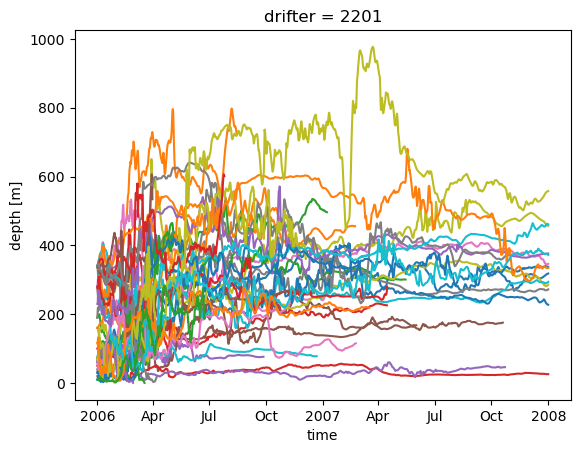

In [3]:
# A mini check to se whether the tracking ran as long as it was supposed to
for drifter in ds.drifter[::50]:
    ds.depth.sel(drifter=drifter).plot()

## Pick Subduction (PW encounter & descent)

In [ ]:
logger = hlp.get_logger(log_level="WARNING", name="subduction_analysis")
# Choosing the logging level DEBUG will not just give you more prints but also also genenerate one plot per particle, 
# so you should only use it for smaller particle subsets like `drifter_sample`

In [6]:
MIN_DAYS  = 7
MIN_STEPS = STEPS_PER_DAY * MIN_DAYS


# Main loop
records = []
n_total = ds.drifter.shape[0]
n_no_subduction = 0
n_too_deep = 0
n_no_drop = 0

drifter_sample = np.random.choice(ds.drifter.shape[0], size=10, replace=False)

for drifter in tqdm(range(n_total)): #tqdm(drifter_sample): # 
    t0 = find_first_subduction(drifter, ds, MIN_STEPS, STEPS_PER_DAY)
    if t0 is None:
        n_no_subduction += 1
        continue

    # check if particle is too deep before calling pick_drop_idx
    if ds.depth.isel(drifter=drifter, time=slice(0, t0)).min() > 150:
        #debug_plot(drifter, ds, t0, limit=150)
        n_too_deep += 1
        records.append(extract_properties(drifter, t0, ds, STEPS_PER_DAY, category='too_deep'))
        continue  

    drop_idx, start_idx, stop_idx, resurf_warning_str = pick_drop_idx(t0, ds, drifter, STEPS_PER_DAY, logger, SIGMA_DAYS=60)
    if drop_idx is None:
        n_no_drop += 1
        records.append(extract_properties(drifter, t0, ds, STEPS_PER_DAY, category='no_drop'))
        continue

    #records.append(extract_properties(drifter, t0, int(start_idx), int(drop_idx), ds, STEPS_PER_DAY))
    records.append(extract_properties(drifter, t0, ds, STEPS_PER_DAY,
                                      start_idx=start_idx, drop_idx=drop_idx, stop_idx=stop_idx, resurf_warning_str=resurf_warning_str))

results = pd.DataFrame(records)

n_success = len(records)

print(f"\n{'='*30}")
print(f" DRIFTER PROCESSING SUMMARY")
print(f"{'='*30}")
print(f"Total processed:    {n_total}")
print(f"Successfully saved: {n_success} ({(n_success/n_total)*100:.1f}%)")
print(f"{'-'*30}")
print(f"Skipped - No subduction:  {n_no_subduction}")
print(f"Saved but - Too deep:       {n_too_deep}")
print(f"Saved but - No drop found:  {n_no_drop}")
print(f"{'='*30}")

  0%|          | 6/2237 [00:00<03:47,  9.80it/s]

Drifter 2: particle resurfaces after drop — consider another peak


  1%|          | 12/2237 [00:01<02:26, 15.23it/s]

Drifter 6: particle resurfaces after drop — consider another peak


  1%|▏         | 29/2237 [00:02<02:30, 14.65it/s]

...

Drifter 1943: particle resurfaces after drop — consider another peak


 90%|█████████ | 2019/2237 [01:39<00:05, 36.68it/s]

Drifter 2010: window too small, using daily window [1210, 1222]


 97%|█████████▋| 2171/2237 [01:47<00:03, 17.23it/s]/albedo/home/quraus001/miniforge3/envs/pyfesom_env/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
 98%|█████████▊| 2202/2237 [01:48<00:01, 25.60it/s]/albedo/home/quraus001/miniforge3/envs/pyfesom_env/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
100%|██████████| 2237/2237 [01:49<00:00, 20.37it/s]

Drifter 2235: window too small, using daily window [927, 939]

 DRIFTER PROCESSING SUMMARY
Total processed:    2237
Successfully saved: 1689 (75.5%)
------------------------------
Skipped - No subduction:  548
Saved but - Too deep:       289
Saved but - No drop found:  151


## Control

In [7]:
results

,drifter_idx,category,warning,time,time_drop,time_start,time_stop,datetime,datetime_drop,datetime_start,...,Ro_90_descent,Ro_max_descent,strain_mean_descent,strain_max_descent,strain_90_descent,okubo_weiss_mean_descent,okubo_weiss_max_descent,depth_mean_descent,depth_min_descent,depth_max_descent
0,0,subduction,None,1246,691.0,443.0,881.0,2006-04-14 20:00:00,2006-02-27 14:00:00,2006-02-06 22:00:00,...,0.411704,0.892124,0.000022,0.000086,0.000050,-1.160209e-10,-1.508966e-08,33.378687,8.330274,94.237422
1,1,subduction,,1056,1077.0,919.0,1374.0,2006-03-30 00:00:00,2006-03-31 18:00:00,2006-03-18 14:00:00,...,0.229018,-0.349977,0.000019,0.000035,0.000029,-5.867438e-11,-1.440195e-09,97.127703,63.506861,145.246189
2,2,subduction,resurface warning,3583,1137.0,235.0,1262.0,2006-10-26 14:00:00,2006-04-05 18:00:00,2006-01-20 14:00:00,...,0.203645,0.458411,0.000013,0.000073,0.000028,4.678407e-12,-1.789723e-09,78.456073,9.728631,162.058792
3,3,subduction,None,1051,738.0,360.0,1241.0,2006-03-29 14:00:00,2006-03-03 12:00:00,2006-01-31 00:00:00,...,0.367530,0.591426,0.000028,0.000091,0.000059,2.692550e-10,-4.917324e-09,35.857127,7.716625,143.825198
4,5,subduction,,3049,3139.0,907.0,3535.0,2006-09-12 02:00:00,2006-09-19 14:00:00,2006-03-17 14:00:00,...,0.199626,0.333025,0.000011,0.000049,0.000025,-6.226985e-11,-1.427224e-09,128.157348,44.300619,196.174917
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1684,2229,subduction,,983,974.0,554.0,1248.0,2006-03-23 22:00:00,2006-03-23 04:00:00,2006-02-16 04:00:00,...,0.255578,0.387888,0.000018,0.000043,0.000030,-1.744779e-10,-1.748531e-09,105.386791,16.041383,218.652640
1685,2230,no_drop,,1159,NaN,NaN,NaN,2006-04-07 14:00:00,NaT,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1686,2231,subduction,,2764,2648.0,1793.0,3032.0,2006-08-19 08:00:00,2006-08-09 16:00:00,2006-05-30 10:00:00,...,0.041047,0.067447,0.000007,0.000015,0.000011,4.262217e-11,1.789810e-10,274.223848,233.896722,303.703629
1687,2232,subduction,,947,1119.0,919.0,1424.0,2006-03-20 22:00:00,2006-04-04 06:00:00,2006-03-18 14:00:00,...,0.266279,0.338343,0.000023,0.000048,0.000040,1.758714e-10,1.447689e-09,52.278955,30.031590,73.712855


In [8]:
no_drop   = results[results['category'] == 'too_deep']

/tmp/ipykernel_436392/1613319689.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pw_time_idx = no_drop[results['drifter_idx'] == drifter]["time"].values
/tmp/ipykernel_436392/1613319689.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pw_time_idx = no_drop[results['drifter_idx'] == drifter]["time"].values
/tmp/ipykernel_436392/1613319689.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pw_time_idx = no_drop[results['drifter_idx'] == drifter]["time"].values
/tmp/ipykernel_436392/1613319689.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pw_time_idx = no_drop[results['drifter_idx'] == drifter]["time"].values
/tmp/ipykernel_436392/1613319689.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pw_time_idx = no_drop[results['drifter_idx'] == drifter]["time"].values


[2774]
[1846]
[4174]
[5673]
[523]


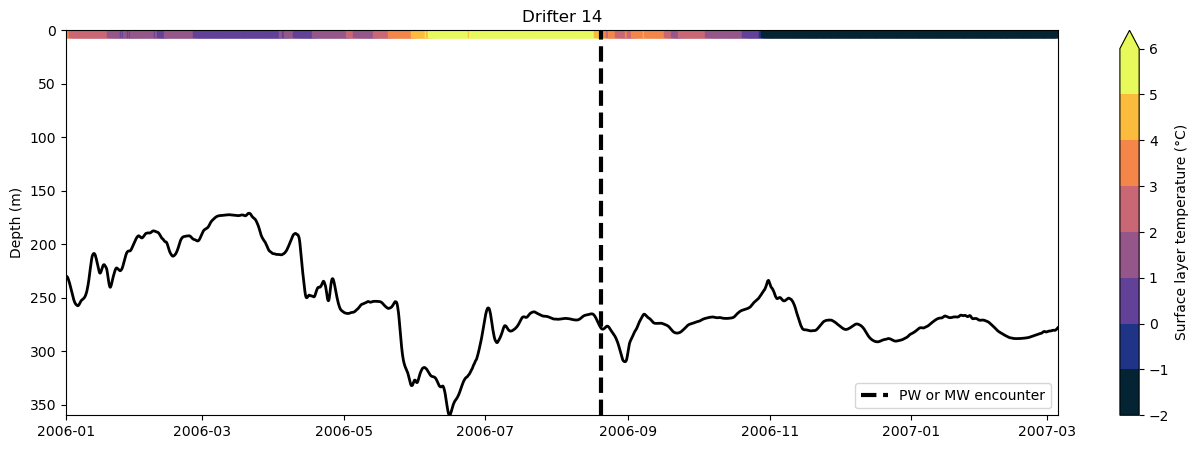

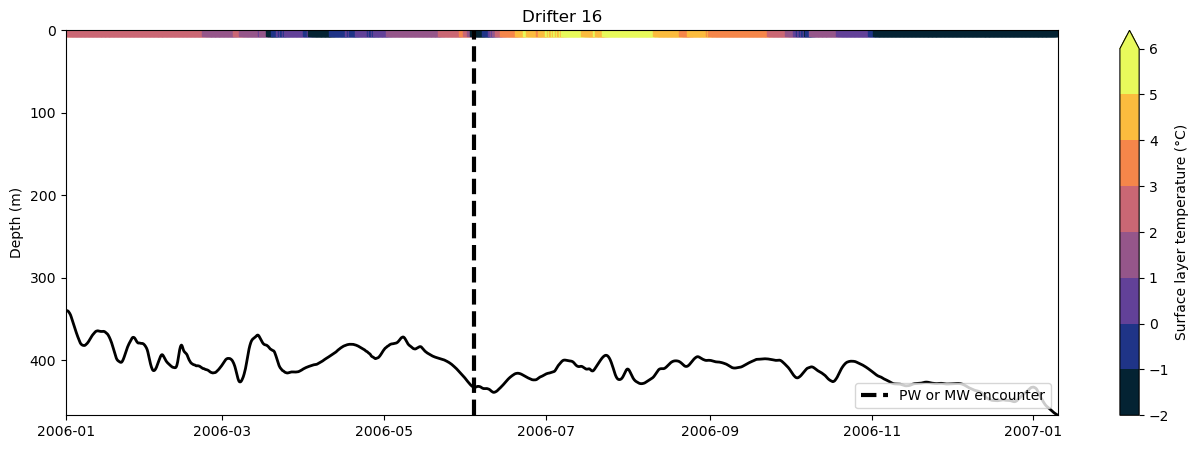

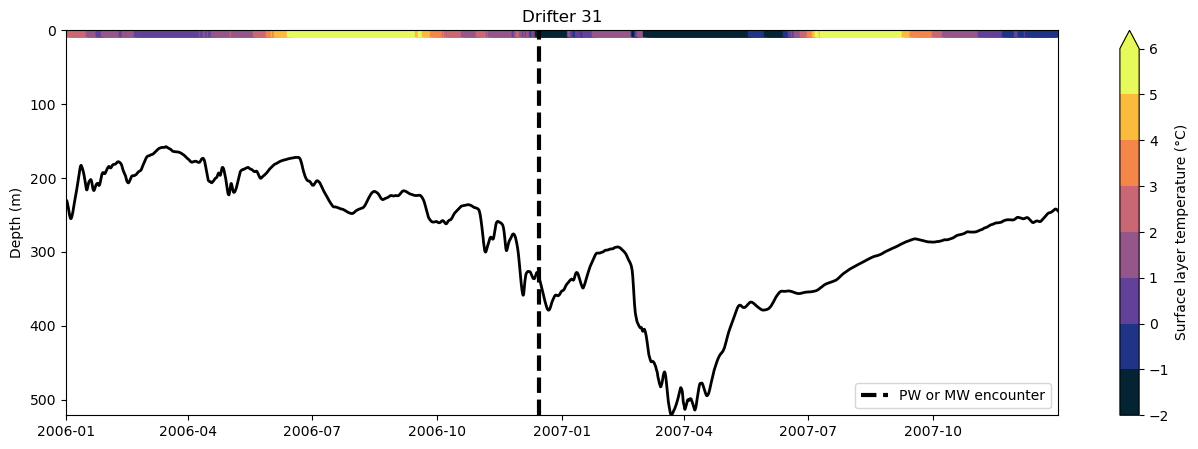

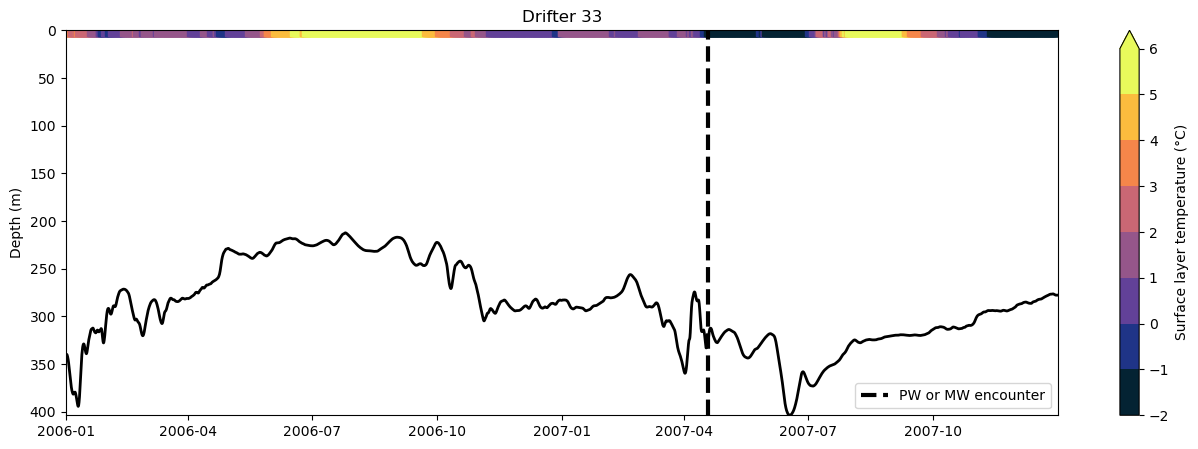

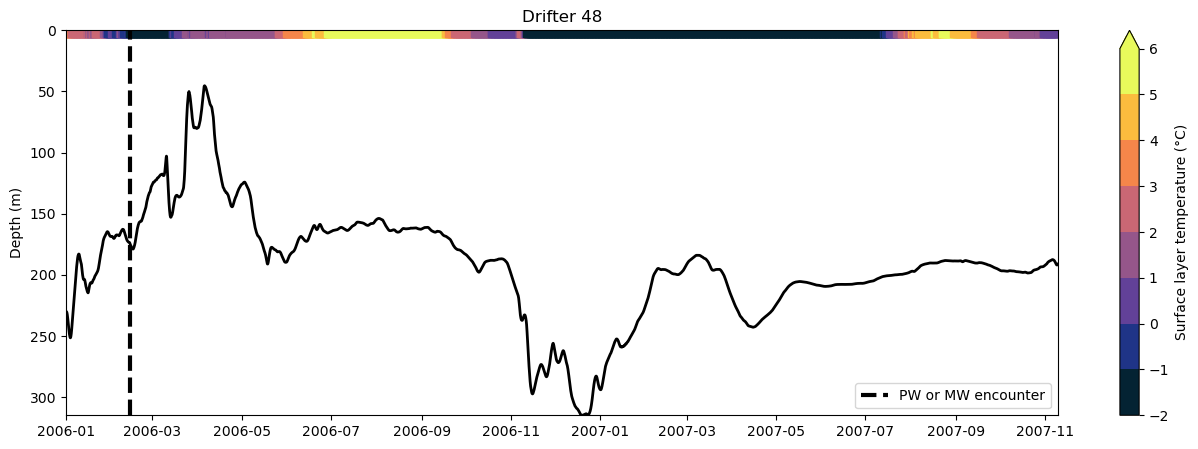

In [10]:
for drifter in no_drop["drifter_idx"][:5]:
    pw_time_idx = no_drop[results['drifter_idx'] == drifter]["time"].values
    print(pw_time_idx)
    debug_plot(drifter, ds, pw_time_idx, limit=None)

## Save as .csv

In [ ]:
import datetime


name = filename.removesuffix(".nc").removeprefix("drifter_output_")
outfile = f"{outpath}Subduction-idxs_{name}.csv"

print(f"Writing to {outfile}...")

# --- Overwrite Guard Condition ---
proceed = True
if os.path.exists(outfile):
    response = (
        input(f"Warning: '{outfile}' already exists. Overwrite? (y/N): ")
        .strip()
        .lower()
    )
    if response not in ["y", "yes"]:
        proceed = False
        print("Operation cancelled. Existing file left untouched.")

# Only execute if safe to proceed
if proceed:
    header_lines = [
    f"# Created:             {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}",
    f"# Source drifter file: {ds.attrs.get('start_position_file', 'unknown')}",
    f"# Drifter output file: {filename}",
    f"# Release year:        {ds.attrs.get('release_start_year', 'unknown')}",
    f"# Release DOY:         {ds.attrs.get('release_start_doy', 'unknown')}",
    f"#",
    f"# --- Processing Summary ---",
    f"# Total processed:    {n_total}",
    f"# Successfully saved: {n_success} ({(n_success/n_total)*100:.1f}%)",
    f"# Skipped - No subduction:  {n_no_subduction} ({(n_no_subduction/n_total)*100:.1f}%)",
    f"# Skipped - Too deep:       {n_too_deep} ({(n_too_deep/n_total)*100:.1f}%)",
    f"# Skipped - No drop found:  {n_no_drop} ({(n_no_drop/n_total)*100:.1f}%)",
    f"#",
    ]

    with open(outfile, "w") as f:
        f.write("\n".join(header_lines) + "\n")

    results.to_csv(outfile, mode="a", index=False)

Writing to /albedo/work/user/quraus001/FESOM_particles/result/processed_results/Subduction-idxs_2006-001_lat-76_particles-2640_tracking-730d_2026-05-20.csv...
Operation cancelled. Existing file left untouched.
